In [ ]:
# Imports and Spark init
from pyspark.sql import SparkSession, functions as F
import pandas as pd
import matplotlib.pyplot as plt

# In cluster use the HDFS path prefix
# path_prefix = "hdfs:///projects/BDA-12/"
# In local use the local path prefix
path_prefix = "" 

spark = SparkSession.builder.appName("NutrientDensityExplorer").getOrCreate()
print("Spark version:", spark.version)

Spark version: 4.0.1


In [ ]:
# Configuration
input_path = f"{path_prefix}/output/nutritional_profiles"
fallback_file = f"{path_prefix}/output/nutritional_profiles/part-00000-c8bad44e-47d3-4d65-81e1-c1a23350546a-c000.snappy.parquet"

# Output and ranking
output_dir = f"{path_prefix}/output/NutrientDensityExplorer"
top_k = 20
order_desc = True           # True = highest first; False = lowest first
unit_choice = "per_kcal"  # Choose: 'per_kcal' or 'per_100kcal'
save_outputs = False       # Set True to write CSV/Parquet outputs
show_chart = True          # Show Top-10 bar chart

# Category and text filters
category_filter = None     # e.g., 'branded_food' or any value in the category column; None = no filter
exclude_allergens = []     # e.g., ['gluten','milk']
dislikes = []              # e.g., ['alcohol','pork']

# Strict schema mapping for this dataset; fall back to fuzzy matching only if missing
strict_schema = True
schema_columns = {
    'id': 'fdc_id',
    'name': 'food_description',
    'category': 'food_type',
    'kcal': 'energy',
    # macros & common
    'protein': 'protein',
    'carb': 'carbs',
    'fat': 'total_fat',
    'fiber': 'fiber',
    'sugar': 'sugars',
    'sodium': 'sodium',
    # lipid details
    'saturated_fat': 'saturated_fat',
    'monounsaturated_fat': 'monounsaturated_fat',
    'polyunsaturated_fat': 'polyunsaturated_fat',
    'trans_fat': 'trans_fat',
    # sugars breakdown
    'glucose': 'glucose',
    'fructose': 'fructose',
    'sucrose': 'sucrose',
    'lactose': 'lactose',
    # other components
    'cholesterol': 'cholesterol',
    'water': 'water',
    'ash': 'ash',
    'alcohol': 'alcohol',
    'caffeine': 'caffeine',
    # minerals
    'calcium': 'calcium',
    'iron': 'iron',
    'magnesium': 'magnesium',
    'phosphorus': 'phosphorus',
    'potassium': 'potassium',
    'sodium_mg': 'sodium', 
    'zinc': 'zinc',
    'copper': 'copper',
    'manganese': 'manganese',
    'selenium': 'selenium',
    # vitamins
    'vitamin_a': 'vitamin_a',
    'vitamin_c': 'vitamin_c',
    'vitamin_d': 'vitamin_d',
    'vitamin_e': 'vitamin_e',
    'vitamin_k': 'vitamin_k',
    'thiamin_b1': 'thiamin_b1',
    'riboflavin_b2': 'riboflavin_b2',
    'niacin_b3': 'niacin_b3',
    'vitamin_b6': 'vitamin_b6',
    'folate': 'folate',
    'vitamin_b12': 'vitamin_b12',
    'choline': 'choline',
    # pigments / carotenoids
    'beta_carotene': 'beta_carotene',
    'lycopene': 'lycopene',
    'lutein_zeaxanthin': 'lutein_zeaxanthin',
    # counts / meta
    'total_nutrients': 'total_nutrients',
}

# Metric selection (toggle multiple)
metrics_available = [
    'protein','fiber','sugar','carb','fat',
    'sodium','saturated_fat','monounsaturated_fat','polyunsaturated_fat','trans_fat',
    'cholesterol','water','ash','alcohol','caffeine',
    'glucose','fructose','sucrose','lactose',
    'calcium','iron','magnesium','phosphorus','potassium','zinc','copper','manganese','selenium',
    'vitamin_a','vitamin_c','vitamin_d','vitamin_e','vitamin_k','thiamin_b1','riboflavin_b2','niacin_b3','vitamin_b6','folate','vitamin_b12','choline',
    'beta_carotene','lycopene','lutein_zeaxanthin',
    # optional meta metric (not density by nature but supported)
    'total_nutrients'
 ]
metric_use = {m: (m=='protein') for m in metrics_available}  # enable protein by default
selected_metric = 'fat'   # used for the on-screen display if multiple enabled

In [ ]:
# Column detection with strict schema fallback
from pyspark.sql import functions as F
import os

def detect_column(df, candidates):
    for cand in candidates:
        for i, col in enumerate(df.columns):
            if col.lower() == cand.lower():
                return df.columns[i]
    for cand in candidates:
        for i, col in enumerate(df.columns):
            if cand.lower() in col.lower():
                return df.columns[i]
    return None

def pick_exact(df, name):
    if not name: return None
    if name in df.columns: return name
    for c in df.columns:
        if c.lower() == str(name).lower():
            return c
    return None

# Read dataset
path = input_path if os.path.exists(input_path) else fallback_file
print('Input path:', path)
df = spark.read.parquet(path)
print('Rows:', df.count())

# Identify base columns
if strict_schema:
    id_col       = pick_exact(df, schema_columns.get('id'))       or detect_column(df, ['fdc_id','id'])
    name_col     = pick_exact(df, schema_columns.get('name'))     or detect_column(df, ['food_description','description','food_name','name','brand_name'])
    category_col = pick_exact(df, schema_columns.get('category')) or detect_column(df, ['food_type','food_category','wweia_food_category','category'])
    kcal_col     = pick_exact(df, schema_columns.get('kcal'))     or detect_column(df, ['energy_kcal','energy','kcal','calories','1008'])
else:
    id_col       = detect_column(df, ['fdc_id','id'])
    name_col     = detect_column(df, ['food_description','description','food_name','name','brand_name'])
    category_col = detect_column(df, ['food_type','food_category','wweia_food_category','category'])
    kcal_col     = detect_column(df, ['energy_kcal','energy','kcal','calories','1008'])

if not (id_col and name_col and kcal_col):
    raise RuntimeError('Missing essential columns (id/name/kcal).')

# Map nutrient columns using schema first, then fuzzy fallback
def map_nutrient(key, fallbacks):
    if strict_schema:
        c = pick_exact(df, schema_columns.get(key))
        if c: return c
    return detect_column(df, fallbacks)

protein_col       = map_nutrient('protein',       ['protein_g','protein','1003'])
carb_col          = map_nutrient('carb',          ['carbohydrate_g','carbohydrates','carb','carbohydrate','1005','carbs'])
fat_col           = map_nutrient('fat',           ['fat_g','fat','total_lipid','total_fat','1004'])
fiber_col         = map_nutrient('fiber',         ['fiber_g','dietary_fiber','fiber','1079'])
sugar_col         = map_nutrient('sugar',         ['sugar_g','sugar','sugars','2000'])
sodium_col        = map_nutrient('sodium',        ['sodium_mg','sodium','1093'])
saturated_fat_col = map_nutrient('saturated_fat', ['saturated_fat','fa_sat','sfa'])
mono_fat_col      = map_nutrient('monounsaturated_fat', ['monounsaturated_fat','fa_mono','mufa'])
poly_fat_col      = map_nutrient('polyunsaturated_fat', ['polyunsaturated_fat','fa_poly','pufa'])
trans_fat_col     = map_nutrient('trans_fat',     ['trans_fat','fa_trans','trans'])
cholesterol_col   = map_nutrient('cholesterol',   ['cholesterol','cholesterol_mg'])

# sugars breakdown
glucose_col       = map_nutrient('glucose',       ['glucose'])
fructose_col      = map_nutrient('fructose',      ['fructose'])
sucrose_col       = map_nutrient('sucrose',       ['sucrose'])
lactose_col       = map_nutrient('lactose',       ['lactose'])

# other components
water_col         = map_nutrient('water',         ['water','water_g'])
ash_col           = map_nutrient('ash',           ['ash','ash_g'])
alcohol_col       = map_nutrient('alcohol',       ['alcohol','alcohol_g'])
caffeine_col      = map_nutrient('caffeine',      ['caffeine','caffeine_mg'])

# minerals
calcium_col       = map_nutrient('calcium',       ['calcium_mg','calcium'])
iron_col          = map_nutrient('iron',          ['iron_mg','iron'])
magnesium_col     = map_nutrient('magnesium',     ['magnesium_mg','magnesium'])
phosphorus_col    = map_nutrient('phosphorus',    ['phosphorus_mg','phosphorus','phosphate'])
potassium_col     = map_nutrient('potassium',     ['potassium_mg','potassium'])
zinc_col          = map_nutrient('zinc',          ['zinc_mg','zinc'])
copper_col        = map_nutrient('copper',        ['copper_mg','copper'])
manganese_col     = map_nutrient('manganese',     ['manganese_mg','manganese'])
selenium_col      = map_nutrient('selenium',      ['selenium_mcg','selenium'])

# vitamins
vitamin_a_col     = map_nutrient('vitamin_a',     ['vitamin_a','retinol','vit_a'])
vitamin_c_col     = map_nutrient('vitamin_c',     ['vitamin_c','vit_c','ascorbic'])
vitamin_d_col     = map_nutrient('vitamin_d',     ['vitamin_d','vit_d'])
vitamin_e_col     = map_nutrient('vitamin_e',     ['vitamin_e','alpha_tocopherol'])
vitamin_k_col     = map_nutrient('vitamin_k',     ['vitamin_k','phylloquinone'])
thiamin_b1_col    = map_nutrient('thiamin_b1',    ['thiamin','thiamine','vitamin_b1','b1'])
riboflavin_b2_col = map_nutrient('riboflavin_b2', ['riboflavin','vitamin_b2','b2'])
niacin_b3_col     = map_nutrient('niacin_b3',     ['niacin','vitamin_b3','b3'])
vitamin_b6_col    = map_nutrient('vitamin_b6',    ['vitamin_b6','pyridoxine','b6'])
folate_col        = map_nutrient('folate',        ['folate','folic_acid'])
vitamin_b12_col   = map_nutrient('vitamin_b12',   ['vitamin_b12','cobalamin','b12'])
choline_col       = map_nutrient('choline',       ['choline'])

# pigments
beta_carotene_col     = map_nutrient('beta_carotene',     ['beta_carotene'])
lycopene_col          = map_nutrient('lycopene',          ['lycopene'])
lutein_zeaxanthin_col = map_nutrient('lutein_zeaxanthin', ['lutein_zeaxanthin','lutein','zeaxanthin'])

# optional meta
total_nutrients_col = map_nutrient('total_nutrients', ['total_nutrients'])

# Choose text column for allergen/dislike filters (ingredients/description fallback)
text_col = detect_column(df, ['ingredients','ingredients_text']) or name_col

print('Detected:', {
    'id': id_col,
    'name': name_col,
    'category': category_col,
    'kcal': kcal_col,
    'protein': protein_col,
    'carb': carb_col,
    'fat': fat_col,
    'fiber': fiber_col,
    'sugar': sugar_col,
    'sodium': sodium_col,
    'saturated_fat': saturated_fat_col,
    'monounsaturated_fat': mono_fat_col,
    'polyunsaturated_fat': poly_fat_col,
    'trans_fat': trans_fat_col,
    'cholesterol': cholesterol_col,
    'glucose': glucose_col,
    'fructose': fructose_col,
    'sucrose': sucrose_col,
    'lactose': lactose_col,
    'water': water_col,
    'ash': ash_col,
    'alcohol': alcohol_col,
    'caffeine': caffeine_col,
    'potassium': potassium_col,
    'calcium': calcium_col,
    'iron': iron_col,
    'magnesium': magnesium_col,
    'phosphorus': phosphorus_col,
    'zinc': zinc_col,
    'copper': copper_col,
    'manganese': manganese_col,
    'selenium': selenium_col,
    'vitamin_a': vitamin_a_col,
    'vitamin_c': vitamin_c_col,
    'vitamin_d': vitamin_d_col,
    'vitamin_e': vitamin_e_col,
    'vitamin_k': vitamin_k_col,
    'thiamin_b1': thiamin_b1_col,
    'riboflavin_b2': riboflavin_b2_col,
    'niacin_b3': niacin_b3_col,
    'vitamin_b6': vitamin_b6_col,
    'folate': folate_col,
    'vitamin_b12': vitamin_b12_col,
    'choline': choline_col,
    'beta_carotene': beta_carotene_col,
    'lycopene': lycopene_col,
    'lutein_zeaxanthin': lutein_zeaxanthin_col,
    'total_nutrients': total_nutrients_col,
    'text': text_col,
})

# Build a dictionary of metric->column for downstream use
metric_columns = {
    'protein': protein_col,
    'fiber': fiber_col,
    'sugar': sugar_col,
    'carb': carb_col,
    'fat': fat_col,
    'sodium': sodium_col,
    'saturated_fat': saturated_fat_col,
    'monounsaturated_fat': mono_fat_col,
    'polyunsaturated_fat': poly_fat_col,
    'trans_fat': trans_fat_col,
    'cholesterol': cholesterol_col,
    'water': water_col,
    'ash': ash_col,
    'alcohol': alcohol_col,
    'caffeine': caffeine_col,
    'glucose': glucose_col,
    'fructose': fructose_col,
    'sucrose': sucrose_col,
    'lactose': lactose_col,
    'potassium': potassium_col,
    'calcium': calcium_col,
    'iron': iron_col,
    'magnesium': magnesium_col,
    'phosphorus': phosphorus_col,
    'zinc': zinc_col,
    'copper': copper_col,
    'manganese': manganese_col,
    'selenium': selenium_col,
    'vitamin_a': vitamin_a_col,
    'vitamin_c': vitamin_c_col,
    'vitamin_d': vitamin_d_col,
    'vitamin_e': vitamin_e_col,
    'vitamin_k': vitamin_k_col,
    'thiamin_b1': thiamin_b1_col,
    'riboflavin_b2': riboflavin_b2_col,
    'niacin_b3': niacin_b3_col,
    'vitamin_b6': vitamin_b6_col,
    'folate': folate_col,
    'vitamin_b12': vitamin_b12_col,
    'choline': choline_col,
    'beta_carotene': beta_carotene_col,
    'lycopene': lycopene_col,
    'lutein_zeaxanthin': lutein_zeaxanthin_col,
    'total_nutrients': total_nutrients_col,
}

# Keep only valid metrics based on data
metrics_available = [m for m in metrics_available if metric_columns.get(m)]
metric_use = {m: (metric_use.get(m, False) and (m in metrics_available)) for m in metric_use}
if selected_metric not in metrics_available:
    selected_metric = next((m for m, on in metric_use.items() if on), None) or (metrics_available[0] if metrics_available else None)
print('Selected metric:', selected_metric)

Input path: ../output/nutritional_profiles
Rows: 4688
Detected: {'id': 'fdc_id', 'name': 'food_description', 'category': 'food_type', 'kcal': 'energy', 'protein': 'protein', 'carb': 'carbs', 'fat': 'total_fat', 'fiber': 'fiber', 'sugar': 'sugars', 'sodium': 'sodium', 'saturated_fat': 'saturated_fat', 'monounsaturated_fat': 'monounsaturated_fat', 'polyunsaturated_fat': 'polyunsaturated_fat', 'trans_fat': 'trans_fat', 'cholesterol': 'cholesterol', 'glucose': 'glucose', 'fructose': 'fructose', 'sucrose': 'sucrose', 'lactose': 'lactose', 'water': 'water', 'ash': 'ash', 'alcohol': 'alcohol', 'caffeine': 'caffeine', 'potassium': 'potassium', 'calcium': 'calcium', 'iron': 'iron', 'magnesium': 'magnesium', 'phosphorus': 'phosphorus', 'zinc': 'zinc', 'copper': 'copper', 'manganese': 'manganese', 'selenium': 'selenium', 'vitamin_a': 'vitamin_a', 'vitamin_c': 'vitamin_c', 'vitamin_d': 'vitamin_d', 'vitamin_e': 'vitamin_e', 'vitamin_k': 'vitamin_k', 'thiamin_b1': 'thiamin_b1', 'riboflavin_b2': 'ri

In [23]:
# Build densities per kcal, per 100kcal, and per 100g for all available metrics
df_base = df.filter(F.col(kcal_col) > 0)
densities = []  # list of tuples: (metric, per_kcal_col, per_100g_col)

for m, colname in metric_columns.items():
    if not colname:
        continue
    # Per-kcal density
    per_kcal_name = f"{m}_per_kcal"
    df_base = df_base.withColumn(per_kcal_name, F.col(colname) / F.col(kcal_col))
    # Per-100kcal (for readability in display)
    per_100kcal_name = f"{m}_per_100kcal"
    df_base = df_base.withColumn(per_100kcal_name, F.col(per_kcal_name) * F.lit(100))
    # Per-100g/raw: assume dataset values are per 100g (or raw serving) as stored
    per_100g_name = f"{m}_per_100g"
    df_base = df_base.withColumn(per_100g_name, F.col(colname))
    densities.append((m, per_kcal_name, per_100g_name))

print("Computed density columns for:", [d[0] for d in densities])

Computed density columns for: ['protein', 'fiber', 'sugar', 'carb', 'fat', 'sodium', 'saturated_fat', 'monounsaturated_fat', 'polyunsaturated_fat', 'trans_fat', 'cholesterol', 'water', 'ash', 'alcohol', 'caffeine', 'glucose', 'fructose', 'sucrose', 'lactose', 'potassium', 'calcium', 'iron', 'magnesium', 'phosphorus', 'zinc', 'copper', 'manganese', 'selenium', 'vitamin_a', 'vitamin_c', 'vitamin_d', 'vitamin_e', 'vitamin_k', 'thiamin_b1', 'riboflavin_b2', 'niacin_b3', 'vitamin_b6', 'folate', 'vitamin_b12', 'choline', 'beta_carotene', 'lycopene', 'lutein_zeaxanthin', 'total_nutrients']


In [24]:
# Apply NO category or text filters (category, allergens, dislikes removed)
df_filt = df_base

# Category filter removed
# Text filters (allergens/dislikes) removed

print("Rows after filtering:", df_filt.count())

Rows after filtering: 4258


In [25]:
# Helpers: select columns and compute Top-K
from IPython.display import display

def select_cols(metric_col):
    cols = []
    for c in [id_col, name_col, kcal_col, category_col]:
        if c: cols.append(c)
    cols.append(metric_col)
    return cols

def topk(df_in, metric_col, desc=True):
    order_col = F.col(metric_col).desc() if desc else F.col(metric_col).asc()
    return df_in.orderBy(order_col).select(*select_cols(metric_col)).limit(top_k)

def to_table_pdf(df_spark, metric_col, title):
    pdf = df_spark.toPandas()
    # styled table
    styler = pdf.style.background_gradient(subset=[metric_col], cmap="YlGn")
    try:
        styler = styler.hide_index()
    except Exception:
        styler = styler.hide(axis="index")
    display(styler.set_caption(title))
    # bar chart
    if show_chart and len(pdf) > 0:
        import textwrap
        top_n = min(10, len(pdf))
        # Prefer declared name_col if present in dataframe
        if 'name_col' in globals() and name_col and name_col in pdf.columns:
            label_series = pdf.iloc[:top_n][name_col].astype(str)
        else:
            label_series = pdf.iloc[:top_n][pdf.columns[1]].astype(str) if pdf.shape[1] > 1 else pdf.index[:top_n].astype(str)
        labels = label_series.tolist()
        values = pdf.iloc[:top_n][metric_col].tolist()
        labels_wrapped = ['\n'.join(textwrap.wrap(l, width=35)) for l in labels]
        n = len(labels_wrapped)
        height = max(2.8, min(0.6 * n + 1.5, 12))
        plt.figure(figsize=(10, height))
        plt.barh(range(n), values, color="#4CAF50")
        plt.yticks(range(n), labels_wrapped, fontsize=9)
        plt.gca().invert_yaxis()  # highest at top
        # annotate values
        for i, v in enumerate(values):
            try:
                plt.text(v, i, f" {v:.3g}", va='center', fontsize=9)
            except Exception:
                pass
        plt.xlabel(metric_col)
        plt.title(title + " (Top 10)")
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
    return pdf

Showing Top-20 for metric: fat (per kcal)


fdc_id,food_description,energy,food_type,fat_per_kcal
1058757,"MAMBO ITALIANO ITALIAN STYLE COMBINATION MEATBALLS & PEPPERONI, PIZZA SAUCE, MOZZARELLA & RICOTTA CHEESES WRAPPED IN AN ARTISAN DOUGH STROMBOLI, MAMBO ITALIANO",32.000000,branded_food,0.524687
1531299,"CASHEW CARAMEL PROTEIN PARADISE MACROBAR, CASHEW CARAMEL",45.000000,branded_food,0.444444
1873157,"CHEESE DIP AND PRETZELS, CHEESE AND PRETZELS",333.000000,branded_food,0.417087
2285068,"GARDEN VEGGIE CREAM CHEESE, WHIPPED",143.000000,branded_food,0.174825
1553810,BUTTERSCOTCH BUTTONS,389.000000,branded_food,0.171388
2408740,"ORGANIC SESAME FLOUR, SESAME FLOUR",98.000000,branded_food,0.153061
517518,RIPE PITTED OLIVES,133.000000,branded_food,0.125338
2671764,"SALTED WHIPPED BUTTER, SALTED",714.000000,branded_food,0.120042
700824,"PITTED SNACK GREEN OLIVES WITH OLIVE OIL, CHILI PEPPER & THYME, GREEN OLIVES WITH OLIVE OIL, CHILI PEPPER & THYME",167.000000,branded_food,0.119760
2445498,QUESO ARROCERO CHEESE FOR RICE,179.000000,branded_food,0.119721


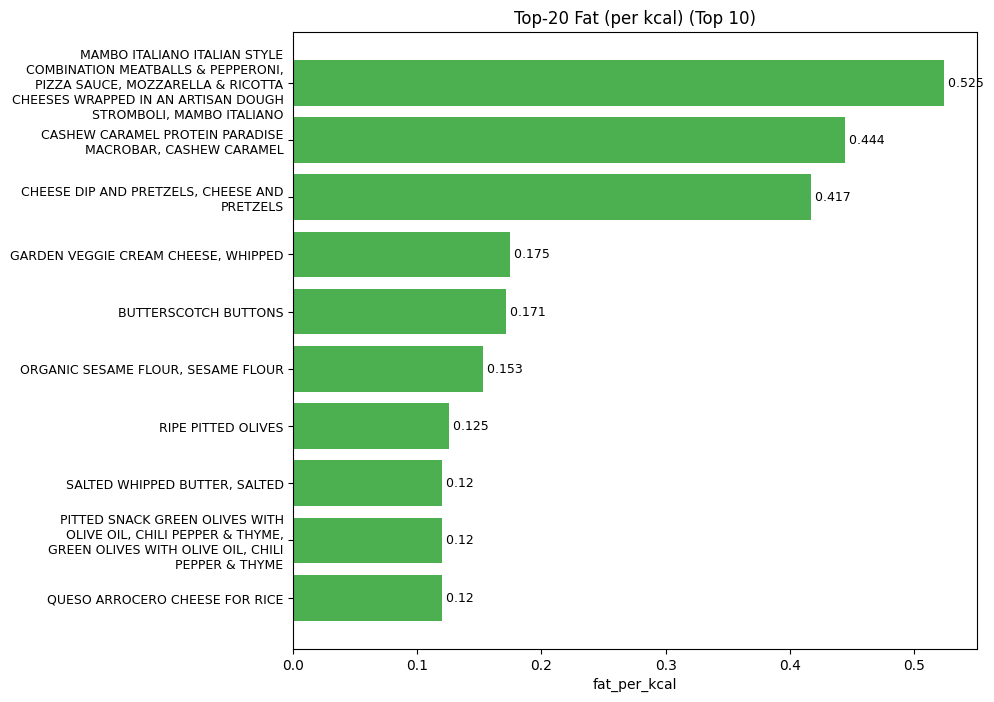

In [26]:
# Compute and display for selected metric (unit selectable)
metric_map = {m: (kcal_col, g_col) for (m, kcal_col, g_col) in densities}
mname = selected_metric if 'selected_metric' in globals() else (display_metric if 'display_metric' in globals() else None)
if not mname or mname not in metric_map:
    print("Selected metric not available:", mname)
else:
    # Determine column by unit_choice
    unit = unit_choice if 'unit_choice' in globals() else 'per_100kcal'
    if unit not in ('per_kcal','per_100kcal'):
        unit = 'per_100kcal'
    m_col = f"{mname}_{unit}" if unit == 'per_100kcal' else f"{mname}_per_kcal"
    # Safety: ensure per_100kcal exists
    if unit == 'per_100kcal' and m_col not in df_filt.columns:
        df_filt = df_filt.withColumn(m_col, F.col(f"{mname}_per_kcal") * F.lit(100))
    res_df = topk(df_filt, m_col, desc=order_desc)
    title_unit = 'per 100 kcal' if unit=='per_100kcal' else 'per kcal'
    print(f"Showing Top-{top_k} for metric: {mname} ({title_unit})")
    _ = to_table_pdf(res_df, m_col, f"Top-{top_k} {mname.replace('_',' ').title()} ({title_unit})")
    if save_outputs:
        base = f"{output_dir}/{mname}"
        suffix = 'per_100kcal' if unit=='per_100kcal' else 'per_kcal'
        (res_df.coalesce(1).write.mode("overwrite").option("header", True).csv(f"{base}/{suffix}_csv"))
        (res_df.write.mode("overwrite").parquet(f"{base}/{suffix}_parquet"))
        print("Saved outputs to:", base)

In [27]:
# Batch save for enabled metrics (unit selectable)
if save_outputs:
    unit = unit_choice if 'unit_choice' in globals() else 'per_100kcal'
    if unit not in ('per_kcal','per_100kcal'):
        unit = 'per_100kcal'
    enabled_metrics = []
    if 'metric_use' in globals():
        enabled_metrics = [m for m, en in metric_use.items() if en and m in metric_map]
    else:
        enabled_metrics = list(metric_map.keys())
    for m in enabled_metrics:
        colname = f"{m}_{unit}" if unit=='per_100kcal' else f"{m}_per_kcal"
        if unit=='per_100kcal' and colname not in df_filt.columns:
            df_filt = df_filt.withColumn(colname, F.col(f"{m}_per_kcal") * F.lit(100))
        base = f"{output_dir}/{m}"
        top_df = topk(df_filt, colname, desc=order_desc)
        (top_df.coalesce(1).write.mode("overwrite").option("header", True).csv(f"{base}/{unit}_csv"))
        (top_df.write.mode("overwrite").parquet(f"{base}/{unit}_parquet"))
    print("Saved batch outputs in", output_dir, "using unit:", unit)